In [1]:
from utilities import * 
from myCGAN import MyCGAN
from myCWGAN import MyCWGAN
import pandas as pd
import numpy as np


# DATA MANAGEMENT and QUALITY

In [ ]:
# data simulation 
# example
X0_range = (0.0,1.0)
mu_range = (0.0, 0.0)
sigma_range = (0.001, 1.0)
T = 1.0        # Time horizon (1 year)
N = 3        # Number of time steps
J = 2        # Number of paths to simulate
SEED=42

# --- Run the Simulation ---
sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

sim.get_paths()
sim.get_pdf(n_steps_ahead=10, n_bins=3)
sim.save_binary_file('data/inputs/demo')
print(sim.paths)
print(sim.pdf)

In [ ]:
file_paths, file_pdf = sim.load_binary_file('data/inputs/demo.bin')

In [ ]:
print(file_paths)
print(file_pdf)

In [2]:
# check quality of montecarlo simulated data

X0_range = (0.0,0.0)
mu_range = (0.0, 0.0)
sigma_range = (0.01, 0.8)
T = 1.0        # Time horizon (1 year)
N = 252        # Number of time steps
J = 100000        # Number of paths to simulate
SEED=42

# --- Run the montecarlo Simulation ---
sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

paths = sim.get_paths()
pdfs= sim.get_pdf(n_steps_ahead=1, n_bins=100, mc_sims=1000)
pdfs.shape 

# --- Run the true theoretical Simulation ---
sim_theory = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

paths_theory = sim_theory.get_paths()
pdfs_theory= sim_theory.get_pdf(n_steps_ahead=1, n_bins=100)
pdfs_theory.shape

(100000, 100)

In [3]:
result = compute_js(pdfs, pdfs_theory)
print(np.nanmean(result))

c:\Users\matte\LEARNING\MAGISTRALE\QUANTITATIVE FINANCE\TESI\cGAN_code\.venv\Lib\site-packages\scipy\spatial\distance.py:1388: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(js / 2.0)


0.0008681209736041707


In [6]:
# Find indices where result is NaN
nan_indices = np.where(np.isnan(result))[0]

print(f"Number of NaN values in result: {len(nan_indices)}")
print(nan_indices)

Number of NaN values in result: 4832
[   20    26    50 ... 99920 99929 99963]


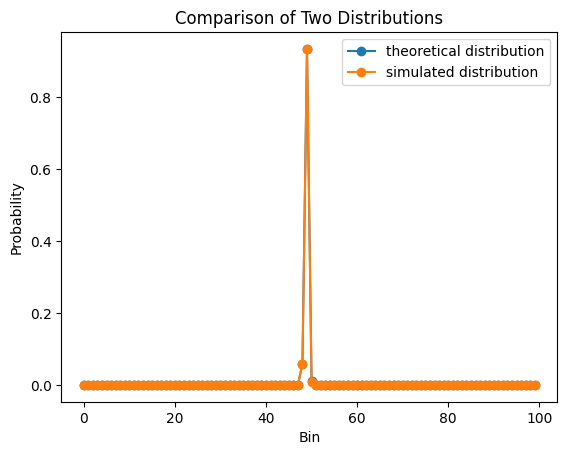

In [7]:
bins = np.arange(len(pdfs_theory[0]))

i = 20
plt.plot(bins, pdfs_theory[i], marker='o', label='theoretical distribution')
plt.plot(bins, pdfs[i], marker='o', label='simulated distribution')
plt.xlabel('Bin')
plt.ylabel('Probability')
plt.title('Comparison of Two Distributions')
plt.legend()
plt.show()

In [8]:
# check quality of montecarlo simulated data

X0_range = (0.0,0.0)
mu_range = (0.0, 0.0)
sigma_range = (0.01, 0.8)
T = 1.0        # Time horizon (1 year)
N = 252        # Number of time steps
J = 100000        # Number of paths to simulate
SEED=42

# --- Run the montecarlo Simulation ---
sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

paths = sim.get_paths()
pdfs = sim.get_pdf(n_bins=0, P=paths[:, -1], n_steps_ahead=1, mc_sims=1000)
pdfs.shape 

# --- Run the true theoretical Simulation ---
sim_theory = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

paths_theory = sim_theory.get_paths()
pdfs_theory= sim_theory.get_pdf(P=paths[:, -1], n_steps_ahead=1, n_bins=None)
pdfs_theory.shape



(100000, 2)

Sample mean: -0.1729, Theoretical mean: -0.1714899024023737
Sample std: 0.0208, Theoretical std: 0.020719905826737477


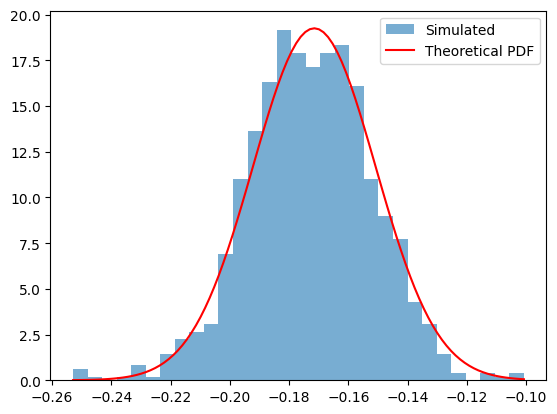

KS statistic: 0.0371, p-value: 0.1247


In [10]:
from scipy.stats import norm, kstest

# A: simulated values, B: [mu, sigma]
i = 0
true = pdfs_theory[i]
mc = pdfs[i]
mu, sigma = true
sample_mean = np.mean(mc)
sample_std = np.std(mc, ddof=1)

print(f"Sample mean: {sample_mean:.4f}, Theoretical mean: {mu}")
print(f"Sample std: {sample_std:.4f}, Theoretical std: {sigma}")

# Plot histogram and theoretical PDF
x = np.linspace(min(mc), max(mc), 100)
plt.hist(mc, bins=int(np.sqrt(len(mc))), density=True, alpha=0.6, label='Simulated')
plt.plot(x, norm.pdf(x, mu, sigma), 'r-', label='Theoretical PDF')
plt.legend()
plt.show()

# Kolmogorov-Smirnov test
ks_stat, p_value = kstest(mc, 'norm', args=(mu, sigma))
print(f"KS statistic: {ks_stat:.4f}, p-value: {p_value:.4f}")

In [11]:
# Assume pdfs_mc is (10000, N), pdfs_theory is (10000, 2) with [mu, sigma] per row
num_rows = pdfs.shape[0]

means = np.mean(pdfs, axis=1)
stds = np.std(pdfs, axis=1, ddof=1)

ks_stats = np.zeros(num_rows)
p_values = np.zeros(num_rows)

for i in range(num_rows):
    mu, sigma = pdfs_theory[i]
    mc = pdfs[i]
    ks_stats[i], p_values[i] = kstest(mc, 'norm', args=(mu, sigma))

# Now means, stds, ks_stats, and p_values contain the results for all rows
print("Mean error:", np.mean(np.abs(means - pdfs_theory[:, 0])))
print("Std error:", np.mean(np.abs(stds - pdfs_theory[:, 1])))
print("Fraction with KS p-value > 0.05:", np.mean(p_values > 0.05))

Mean error: 0.0006446484378847671
Std error: 0.0004545009033880643
Fraction with KS p-value > 0.05: 0.94981


# FORGAN simple

In [46]:
# to train a forgan we simulate the J trajectories and the target output is given by the 1-step ahead value
# so just the path are generated and the last values of each trajectory is used as target 
# at inference time the pdf is the one at 1 day ahead
X0_range = (0.0,0.0)
mu_range = (0.0, 0.0)
sigma_range = (0.01, 0.8)
T = round(22/252, 3)        # Time horizon (monthly)
N = 22        # Number of time steps
# so dt = 22/252 / 22 = 1/252
J = 100000        # Number of paths to simulate
SEED=42

# --- Run the Simulation ---
sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

trajectories = sim.get_paths()
paths = trajectories[:, :-1] #shape JxN-1
targets= trajectories[:, -1:] #shape Jx1
pdfs = sim.get_pdf(n_bins=100, P=paths[:, -1], n_steps_ahead=1)
sim.save_configuration('./models/bins/forgan_simple.json')


Bins saved to models\bins\forgan_simple.json


In [47]:
mydata, _, _ = prepare_data(targets, paths)

generator_params = {"hidden_dims": [128, 256, 128, 64], "use_batch_norm": True}
critic_params = {"hidden_dims": [128, 256, 256, 128, 64], 'use_layer_norm':False}
conditional_gan = MyCGAN(max_epoch=100, name='forgan_simple', z_noise_dim=32)
conditional_gan.set_generator(condition_size=paths.shape[1], output_dim=targets.shape[1], **generator_params)
conditional_gan.set_discriminator(input_size=targets.shape[1], condition_size=paths.shape[1], **critic_params)
conditional_gan.train(mydata, save_history=False, distance_metric='mse')
conditional_gan.save_models() 
stats = conditional_gan.evaluate_error_distribution(mydata, save_to='forgan_simple.csv')


Epoch: 0/100, Step: 0, D Loss: 1.3855443000793457, G Loss: 0.7305158376693726
Epoch: 0/100, Step: 500, D Loss: 0.753774881362915, G Loss: 2.3079800605773926
Epoch: 0/100, Step: 1000, D Loss: 1.2030951976776123, G Loss: 2.339277982711792
Epoch: 0/100, Step: 1500, D Loss: 1.016402006149292, G Loss: 1.8602577447891235
Epoch: 0/100, Step: 2000, D Loss: 1.0905786752700806, G Loss: 2.171835422515869
Epoch: 0/100, Step: 2500, D Loss: 1.1291775703430176, G Loss: 1.642110824584961
Epoch: 0/100, Step: 3000, D Loss: 0.9980693459510803, G Loss: 0.711922287940979
Epoch: 1/100, Step: 3500, D Loss: 1.4122846126556396, G Loss: 1.1464866399765015
Epoch: 1/100, Step: 4000, D Loss: 1.3154385089874268, G Loss: 1.0252625942230225
Epoch: 1/100, Step: 4500, D Loss: 1.0939961671829224, G Loss: 0.9695861339569092
Epoch: 1/100, Step: 5000, D Loss: 1.3834493160247803, G Loss: 0.8745098114013672
Epoch: 1/100, Step: 5500, D Loss: 0.786245584487915, G Loss: 3.216080665588379
Epoch: 1/100, Step: 6000, D Loss: 1.1108

## ks test

In [49]:
# data simulation 
# example

X0_range = (0.0, 0.0)
mu_range = (0.0, 0.0)
sigma_range = (0.05, 0.6)
T = round(22/252, 3)        # Time horizon (monthly)
N = 22        # Number of time steps
J = 1000       # Number of paths to simulate
SEED=2

# --- Run the Simulation ---
sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

trajectories = sim.get_paths()
paths = trajectories[:, :-1] #shape JxN-1
targets= trajectories[:, -1:] #shape Jx1
pdfs = sim.get_pdf(n_bins=0, P=paths[:, -1], n_steps_ahead=1, mc_sims=1000)

# model 
conditional_gan = MyCGAN(max_epoch=100, name='forgan_simple')
conditional_gan.load_models()


mydata, _, _ = prepare_data(targets, paths)
condition, generated = conditional_gan.generate(mydata, get_pdf=True, bins = None)
true_pdfs, generated_pdfs, bin_edges_list = compare_simulated_pdfs(pdfs, generated)

p_values = []
for i, row in enumerate(true_pdfs):
    _, p_value = ks_test_gan_cdf(generated_pdfs[i], row)
    p_values.append(p_value)

test_df = pd.DataFrame({'p_values':p_values})
test_h0 = test_df[test_df['p_values']>0.01]
print("percentage of acceptance of KS test: ", len(test_h0)/len(test_df))

stats = get_error_metrics(true=true_pdfs, generated=generated_pdfs)
for key, metric in stats.items():
    print(key, np.mean(metric))




CGAN config loaded from ./models\forgan_simple_config.json
Generator loaded from ./models\forgan_simple_generator.pth
Architecture: MyGenerator
Parameters: {'latent_size': 32, 'condition_size': 22, 'output_dim': 1, 'hidden_dims': [128, 256, 128, 64], 'is_prob': False, 'use_batch_norm': True, 'activation': 'leaky_relu', 'dropout': 0.0}
Discriminator loaded from ./models\forgan_simple_discriminator.pth
Architecture: MyDiscriminator
Parameters: {'input_size': 1, 'condition_size': 22, 'output_dim': 1, 'hidden_dims': [128, 256, 256, 128, 64], 'use_layer_norm': False, 'activation': 'leaky_relu', 'dropout': 0.0}
shape array (1000, 1000)
percentage of acceptance of KS test:  0.352
js_distance 0.4912357197101505
hellinger_distance 0.4536272106048258
tv_distance 0.45107645150723735
emd_distance 0.021489969937630547


In [6]:
filepath = "models/forgan_simple_discriminator.pth"
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

checkpoint = torch.load(filepath, map_location=device)
state_dict = checkpoint['model_state_dict']
# Remap 'layer.' to 'layers.' in keys
new_state_dict = {}
for k, v in state_dict.items():
    if k.startswith('layer.'):
        new_k = k.replace('layer.', 'layers.')
    else:
        new_k = k
    new_state_dict[new_k] = v
checkpoint['model_state_dict'] = new_state_dict
torch.save(checkpoint, filepath)

In [58]:
# data simulation 
# example


X0_range = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
mu_range = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
sigma_range = [0.03, 0.07, 0.1, 0.3, 0.5, 0.7]
T = round(22/252, 3)        # Time horizon (monthly)
N = 22        # Number of time steps
J = 6       # Number of paths to simulate
SEED=2

#generate
val = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

val.load_configuration('./models/bins/forgan_simple.json')
trajectories = val.get_paths()
paths = trajectories[:, :-1] #shape JxN-1
targets= trajectories[:, -1:] #shape Jx1
pdfs = val.get_pdf(n_bins=0, P=paths[:, -1], n_steps_ahead=1, mc_sims=1000)

conditional_gan = MyCGAN(max_epoch=100, name='forgan_simple')
conditional_gan.load_models()



mydata, _, _ = prepare_data(targets, paths)
condition, generated = conditional_gan.generate(mydata, get_pdf=True, bins = None)



true_pdfs, generated_pdfs, bin_edges_list = compare_simulated_pdfs(pdfs, generated)

p_values = []
for i, row in enumerate(true_pdfs):
    _, p_value = ks_test_gan_cdf(generated_pdfs[i], row)
    p_values.append(p_value)

test_df = pd.DataFrame({'p_values':p_values})
test_h0 = test_df[test_df['p_values']>0.01]
print("percentage of acceptance of KS test: ", len(test_h0)/len(test_df))

stats = get_error_metrics(true=true_pdfs, generated=generated_pdfs)
for key, metric in stats.items():
    print(key, np.mean(metric))

Bins loaded from models\bins\forgan_simple.json
Loaded 101 bins
CGAN config loaded from ./models\forgan_simple_config.json
Generator loaded from ./models\forgan_simple_generator.pth
Architecture: MyGenerator
Parameters: {'latent_size': 32, 'condition_size': 22, 'output_dim': 1, 'hidden_dims': [128, 256, 128, 64], 'is_prob': False, 'use_batch_norm': True, 'activation': 'leaky_relu', 'dropout': 0.0}
Discriminator loaded from ./models\forgan_simple_discriminator.pth
Architecture: MyDiscriminator
Parameters: {'input_size': 1, 'condition_size': 22, 'output_dim': 1, 'hidden_dims': [128, 256, 256, 128, 64], 'use_layer_norm': False, 'activation': 'leaky_relu', 'dropout': 0.0}
shape array (6, 1000)
percentage of acceptance of KS test:  0.3333333333333333
js_distance 0.45389624983980187
hellinger_distance 0.41172480769002306
tv_distance 0.4100042735042735
emd_distance 0.01497676282051282


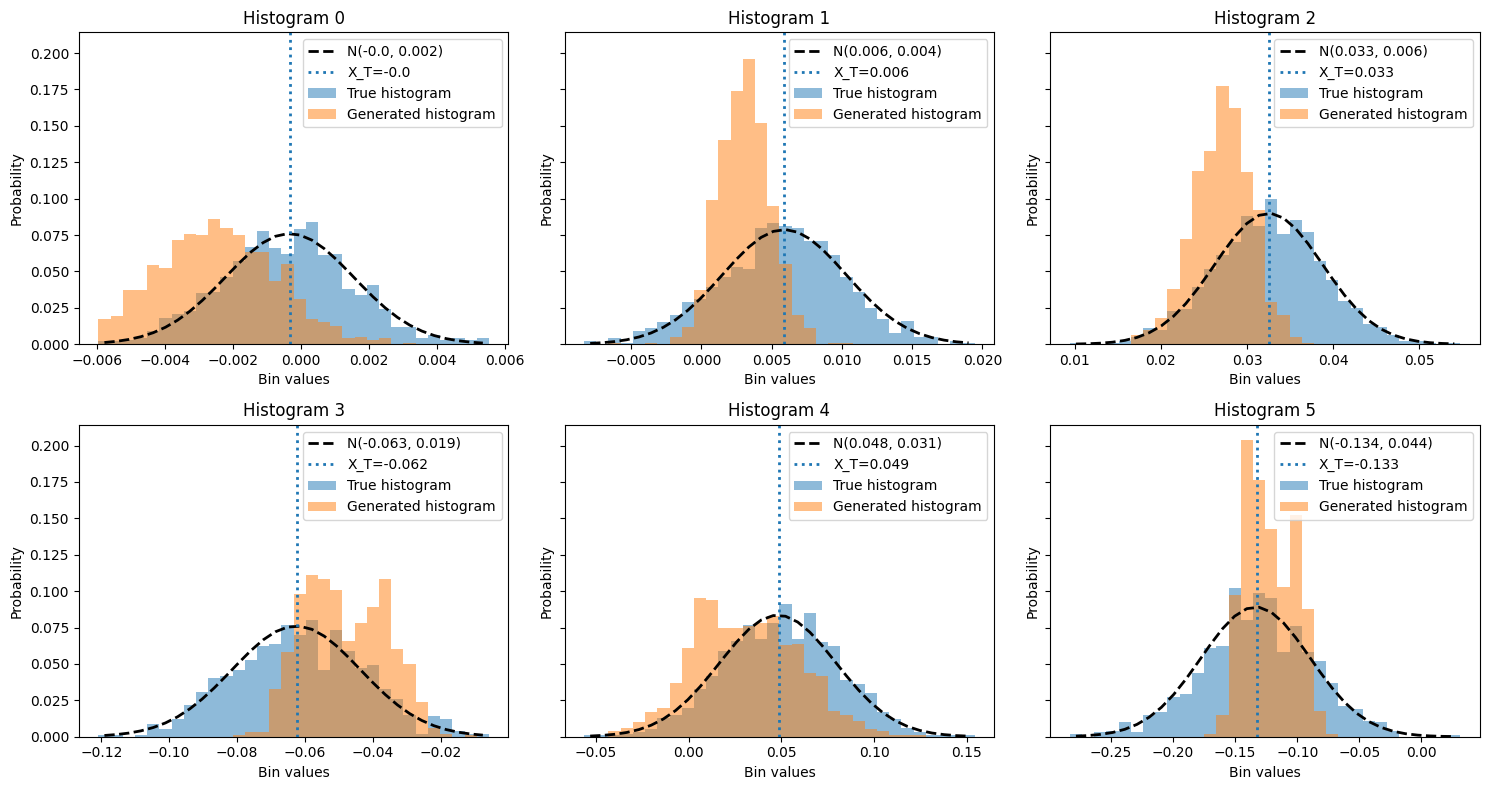

In [59]:
means = sim.means
stds = sim.stds
plot_bin_dist(true_pdfs, generated_pdfs,
            bins_values=bin_edges_list,
            X_T=paths[:, -1],
            stds=stds,
            means=means,
            zoom=False)

# FORGAN

In [ ]:
# to train a forgan we simulate the J trajectories and the target output is given by the 1-step ahead value
# so just the path are generated and the last values of each trajectory is used as target 
# at inference time the pdf is the one at 1 day ahead
X0_range = (0.0,0.0)
mu_range = (0.0, 0.0)
sigma_range = (0.01, 0.8)
T = round(22/252, 3)        # Time horizon (monthly)
N = 22        # Number of time steps
J = 100000        # Number of paths to simulate
SEED=42

# --- Run the Simulation ---
sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

trajectories = sim.get_paths()
paths = trajectories[:, :-1] #shape JxN-1
targets= trajectories[:, -1:] #shape Jx1
pdfs = sim.get_pdf(n_bins=100, P=paths[:, -1], n_steps_ahead=1)
sim.save_configuration('./models/bins/forgan_v3.json')

Bins saved to models\bins\forgan_v3.json


In [ ]:
mydata, _, _ = prepare_data(targets, paths)

generator_params = {"hidden_dims": [128, 256, 128, 64], "use_batch_norm": False}
critic_params = {"hidden_dims": [128, 256, 256, 128, 64], 'use_layer_norm':True}
conditional_gan = MyCWGAN(max_epoch=100, name='forgan_v3', z_noise_dim=32)
conditional_gan.set_generator(condition_size=paths.shape[1], output_dim=targets.shape[1], **generator_params)
conditional_gan.set_discriminator(input_size=targets.shape[1], condition_size=paths.shape[1], **critic_params)
conditional_gan.train(mydata, save_history=False, early_stopping_waiting=10, distance_metric='mse')
conditional_gan.save_models() 


Epoch: 0/100, Step: 500, C_loss: 3.0244, G_loss: -1.3224, W_dist: -0.3128, GP: 0.2712
Epoch: 0/100, Step: 1000, C_loss: 9.6361, G_loss: -1.3554, W_dist: 0.2671, GP: 0.9903
Epoch: 0/100, Step: 1500, C_loss: -1.1091, G_loss: -0.9420, W_dist: 1.2279, GP: 0.0119
Epoch: 0/100, Step: 2000, C_loss: 6.0950, G_loss: -5.0477, W_dist: -3.9581, GP: 0.2137
Epoch: 0/100, Step: 2500, C_loss: -4.4792, G_loss: 2.2846, W_dist: 4.6151, GP: 0.0136
Epoch: 0/100, Step: 3000, C_loss: 5.9281, G_loss: -5.6419, W_dist: -3.7900, GP: 0.2138
Epoch: 1/100, Step: 3500, C_loss: -5.7181, G_loss: 1.8773, W_dist: 6.0463, GP: 0.0328
Epoch: 1/100, Step: 4000, C_loss: 1.8068, G_loss: -6.9108, W_dist: -0.7086, GP: 0.1098
Epoch: 1/100, Step: 4500, C_loss: 5.3500, G_loss: -7.6527, W_dist: -4.0230, GP: 0.1327
Epoch: 1/100, Step: 5000, C_loss: 5.7475, G_loss: -8.8454, W_dist: -3.5455, GP: 0.2202
Epoch: 1/100, Step: 5500, C_loss: 2.9515, G_loss: -7.4819, W_dist: -2.4463, GP: 0.0505
Epoch: 1/100, Step: 6000, C_loss: 2.9055, G_los

## KS test 

In [54]:
# data simulation 
# example

X0_range = (0.0, 0.0)
mu_range = (0.0, 0.0)
sigma_range = (0.05, 0.6)
T = round(22/252, 3)        # Time horizon (monthly)
N = 22        # Number of time steps
J = 1000       # Number of paths to simulate
SEED=2

sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

sim.load_configuration('./models/bins/forgan_v3.json')
trajectories = sim.get_paths()
paths = trajectories[:, :-1] #shape JxN-1
targets= trajectories[:, -1:] #shape Jx1
pdfs = sim.get_pdf(n_bins=0, P=paths[:, -1], n_steps_ahead=1, mc_sims=1000)

# model 
conditional_gan = MyCWGAN(max_epoch=100, name='forgan_v3')
conditional_gan.load_models()


mydata, _, _ = prepare_data(targets, paths)
condition, generated = conditional_gan.generate(mydata, get_pdf=True, bins = None)

true_pdfs, generated_pdfs, bin_edges_list = compare_simulated_pdfs(pdfs, generated)

p_values = []
for i, row in enumerate(true_pdfs):
    _, p_value = ks_test_gan_cdf(generated_pdfs[i], row)
    p_values.append(p_value)

test_df = pd.DataFrame({'p_values':p_values})
test_h0 = test_df[test_df['p_values']>0.01]
print("percentage of acceptance of KS test: ", len(test_h0)/len(test_df))

stats = get_error_metrics(true=true_pdfs, generated=generated_pdfs)
for key, metric in stats.items():
    print(key, np.mean(metric))




Bins loaded from models\bins\forgan_v3.json
Loaded 101 bins
CGAN config loaded from ./models\forgan_v3_config.json
Generator loaded from ./models\forgan_v3_generator.pth
Architecture: MyGenerator
Parameters: {'latent_size': 32, 'condition_size': 22, 'output_dim': 1, 'hidden_dims': [128, 256, 128, 64], 'is_prob': False, 'use_batch_norm': False, 'activation': 'leaky_relu', 'dropout': 0.0}
Discriminator loaded from ./models\forgan_v3_discriminator.pth
Architecture: MyDiscriminator
Parameters: {'input_size': 1, 'condition_size': 22, 'output_dim': 1, 'hidden_dims': [128, 256, 256, 128, 64], 'use_layer_norm': True, 'activation': 'leaky_relu', 'dropout': 0.0}
shape array (1000, 1000)
percentage of acceptance of KS test:  0.956
js_distance 0.26827268349753947
hellinger_distance 0.23542856573376453
tv_distance 0.23377493214249337
emd_distance 0.01107241573371633


### visual

In [55]:
# data simulation 
# example

X0_range = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
mu_range = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
sigma_range = [0.03, 0.07, 0.1, 0.3, 0.5, 0.7]
T = round(22/252, 3)        # Time horizon (monthly)
N = 22        # Number of time steps
J = 6       # Number of paths to simulate
SEED=2

sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

trajectories = sim.get_paths()
paths = trajectories[:, :-1] #shape JxN-1
targets= trajectories[:, -1:] #shape Jx1
pdfs = sim.get_pdf(n_bins=0, P=paths[:, -1], n_steps_ahead=1, mc_sims=1000)

# model 
conditional_gan = MyCWGAN(max_epoch=100, name='forgan_v3')
conditional_gan.load_models()


mydata, _, _ = prepare_data(targets, paths)
condition, generated = conditional_gan.generate(mydata, get_pdf=True, bins = None)

true_pdfs, generated_pdfs, bin_edges_list = compare_simulated_pdfs(pdfs, generated)

p_values = []
for i, row in enumerate(true_pdfs):
    _, p_value = ks_test_gan_cdf(generated_pdfs[i], row)
    p_values.append(p_value)

test_df = pd.DataFrame({'p_values':p_values})
test_h0 = test_df[test_df['p_values']>0.01]
print("percentage of acceptance of KS test: ", len(test_h0)/len(test_df))

stats = get_error_metrics(true=true_pdfs, generated=generated_pdfs)
for key, metric in stats.items():
    print(key, np.mean(metric))


CGAN config loaded from ./models\forgan_v3_config.json
Generator loaded from ./models\forgan_v3_generator.pth
Architecture: MyGenerator
Parameters: {'latent_size': 32, 'condition_size': 22, 'output_dim': 1, 'hidden_dims': [128, 256, 128, 64], 'is_prob': False, 'use_batch_norm': False, 'activation': 'leaky_relu', 'dropout': 0.0}
Discriminator loaded from ./models\forgan_v3_discriminator.pth
Architecture: MyDiscriminator
Parameters: {'input_size': 1, 'condition_size': 22, 'output_dim': 1, 'hidden_dims': [128, 256, 256, 128, 64], 'use_layer_norm': True, 'activation': 'leaky_relu', 'dropout': 0.0}
shape array (6, 1000)
percentage of acceptance of KS test:  1.0
js_distance 0.35733844368029044
hellinger_distance 0.3165939140928644
tv_distance 0.31691043901440624
emd_distance 0.01519308723864661


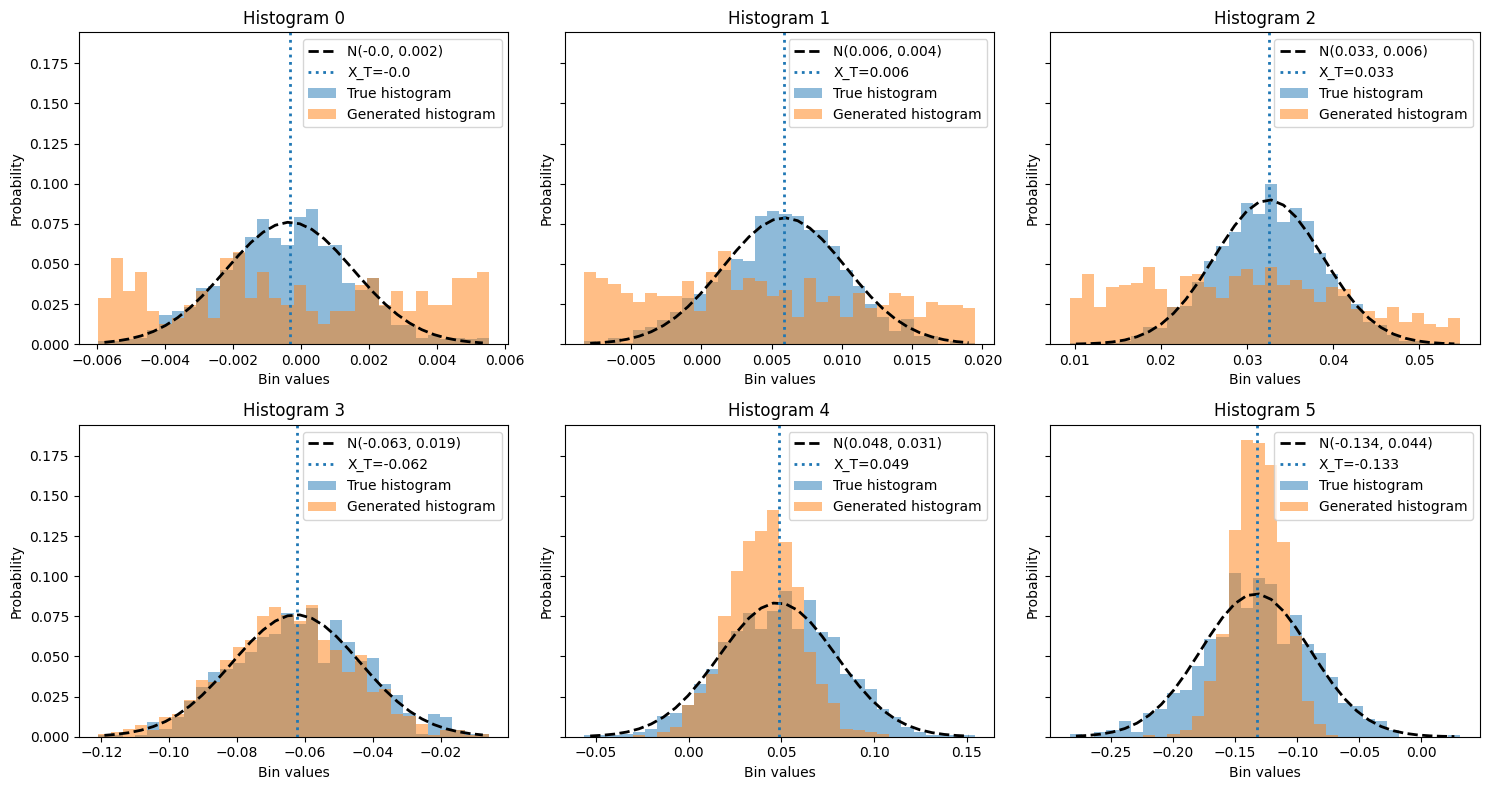

In [57]:
means = sim.means
stds = sim.stds
plot_bin_dist(true_pdfs, generated_pdfs,
            bins_values=bin_edges_list,
            X_T=paths[:, -1],
            stds=stds,
            means=means,
            zoom=False)

# FORGAN 2 params

In [16]:
# to train a forgan we simulate the J trajectories and the target output is given by the 1-step ahead value
# so just the path are generated and the last values of each trajectory is used as target 
# at inference time the pdf is the one at 1 day ahead
X0_range = (0.0, 0.0)
mu_range = (0.0, 0.0)
sigma_range = (0.5, 0.5)
T = 1.0        # Time horizon (1 year)
N = 253        # Number of time steps
J = 100000        # Number of paths to simulate
SEED=42

# --- Run the Simulation ---
sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

trajectories = sim.get_paths(get_proxy_n=2)
trajectories


array([[ 0.5       , -0.30228534, -0.31041222],
       [ 0.5       ,  0.32629368,  0.29052855],
       [ 0.5       , -0.28817646, -0.27540564],
       ...,
       [ 0.5       ,  1.16569064,  1.1777627 ],
       [ 0.5       , -0.93899815, -0.89581205],
       [ 0.5       , -0.07348507, -0.12749879]], shape=(100000, 3))

In [17]:
paths = trajectories[:, :-1] #shape JxN-1
targets= trajectories[:, -1:] #shape Jx1
pdfs = sim.get_pdf(n_bins=100, P=paths[:, -1], n_steps_ahead=1)
sim.save_configuration('./models/bins/forgan_debug.json')

mydata, _, _ = prepare_data(targets, paths)

generator_params = {"hidden_dims": [64, 128, 64], "use_batch_norm":False}
critic_params = {"hidden_dims": [64, 128, 128, 64, 32], 'use_layer_norm':False}
conditional_gan = MyCGAN(max_epoch=100, name='forgan_debug', z_noise_dim=32)
conditional_gan.set_generator(condition_size=paths.shape[1], output_dim=targets.shape[1], **generator_params)
conditional_gan.set_discriminator(input_size=targets.shape[1], condition_size=paths.shape[1], **critic_params)
conditional_gan.train(mydata, save_history=False, distance_metric='mse')
conditional_gan.save_models() 
stats = conditional_gan.evaluate_error_distribution(mydata, save_to='forgan_debug.csv')


Bins saved to models\bins\forgan_debug.json
Epoch: 0/100, Step: 0, D Loss: 1.3854374885559082, G Loss: 0.6683651804924011
Epoch: 0/100, Step: 500, D Loss: 0.924598217010498, G Loss: 2.603760242462158
Epoch: 0/100, Step: 1000, D Loss: 1.200094223022461, G Loss: 1.1397247314453125
Epoch: 0/100, Step: 1500, D Loss: 1.23252272605896, G Loss: 1.2290291786193848
Epoch: 0/100, Step: 2000, D Loss: 1.387911081314087, G Loss: 0.820010244846344
Epoch: 0/100, Step: 2500, D Loss: 1.418790340423584, G Loss: 0.757789134979248
Epoch: 0/100, Step: 3000, D Loss: 1.394542932510376, G Loss: 0.7122078537940979
Epoch: 1/100, Step: 3500, D Loss: 1.3655321598052979, G Loss: 0.6738059520721436
Epoch: 1/100, Step: 4000, D Loss: 1.3890886306762695, G Loss: 0.6935595870018005
Epoch: 1/100, Step: 4500, D Loss: 1.3850374221801758, G Loss: 0.6891434788703918
Epoch: 1/100, Step: 5000, D Loss: 1.3863924741744995, G Loss: 0.68467116355896
Epoch: 1/100, Step: 5500, D Loss: 1.392909049987793, G Loss: 0.6930261254310608
E

In [18]:
# data simulation 
# example

X0_range = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
mu_range = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
sigma_range = [0.5, 0.5, 0.5, 0.5, 0.5, 0.5]
T = 1.0        # Time horizon (1 year)
N = 253        # Number of time steps
J = 6       # Number of paths to simulate
SEED=2

sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

trajectories = sim.get_paths(get_proxy_n=2)
paths = trajectories[:, :-1] #shape JxN-1
targets= trajectories[:, -1:] #shape Jx1
pdfs = sim.get_pdf(n_bins=0, P=paths[:, -1], n_steps_ahead=1, mc_sims=1000)

# model 
conditional_gan = MyCGAN(max_epoch=100, name='forgan_debug')
conditional_gan.load_models()

mydata, _, _ = prepare_data(targets, paths)
condition, generated = conditional_gan.generate(mydata, get_pdf=True, bins = None)

true_pdfs, generated_pdfs, bin_edges_list = compare_simulated_pdfs(pdfs, generated)

p_values = []
for i, row in enumerate(true_pdfs):
    _, p_value = ks_test_gan_cdf(generated_pdfs[i], row)
    p_values.append(p_value)

test_df = pd.DataFrame({'p_values':p_values})
test_h0 = test_df[test_df['p_values']>0.01]
print("percentage of acceptance of KS test: ", len(test_h0)/len(test_df))

stats = get_error_metrics(true=true_pdfs, generated=generated_pdfs)
for key, metric in stats.items():
    print(key, np.mean(metric))


CGAN config loaded from ./models\forgan_debug_config.json
Generator loaded from ./models\forgan_debug_generator.pth
Architecture: MyGenerator
Parameters: {'latent_size': 32, 'condition_size': 2, 'output_dim': 1, 'hidden_dims': [64, 128, 64], 'is_prob': False, 'use_batch_norm': False, 'activation': 'leaky_relu', 'dropout': 0.0}
Discriminator loaded from ./models\forgan_debug_discriminator.pth
Architecture: MyDiscriminator
Parameters: {'input_size': 1, 'condition_size': 2, 'output_dim': 1, 'hidden_dims': [64, 128, 128, 64, 32], 'use_layer_norm': False, 'activation': 'leaky_relu', 'dropout': 0.0}
shape array (6, 1000)
percentage of acceptance of KS test:  1.0
js_distance 0.17569587190910785
hellinger_distance 0.152042856300911
tv_distance 0.14399795437181692
emd_distance 0.004946936441855687


In [19]:
means = sim.means
stds = sim.stds

print("means")
for el in generated:
    print(np.mean(el))

print("\n stds")
for el in generated:
    print(np.std(el))

print("\n corrected means")
for el in generated:
    print(np.mean(el) - np.std(el))

print (f'\n means are:{means} \n stds are: {stds}')

means
-0.21251003
-0.8609031
-0.3440313
0.20859568
-1.5322312
-0.85463893

 stds
0.0297412
0.02573825
0.030883215
0.028006759
0.026840352
0.025538616

 corrected means
-0.24225123
-0.8866413
-0.37491453
0.18058892
-1.5590715
-0.88017756

 means are:[-0.20404678 -0.85500134 -0.33013867  0.21769917 -1.53179402 -0.84982394] 
 stds are: [0.03143473 0.03143473 0.03143473 0.03143473 0.03143473 0.03143473]


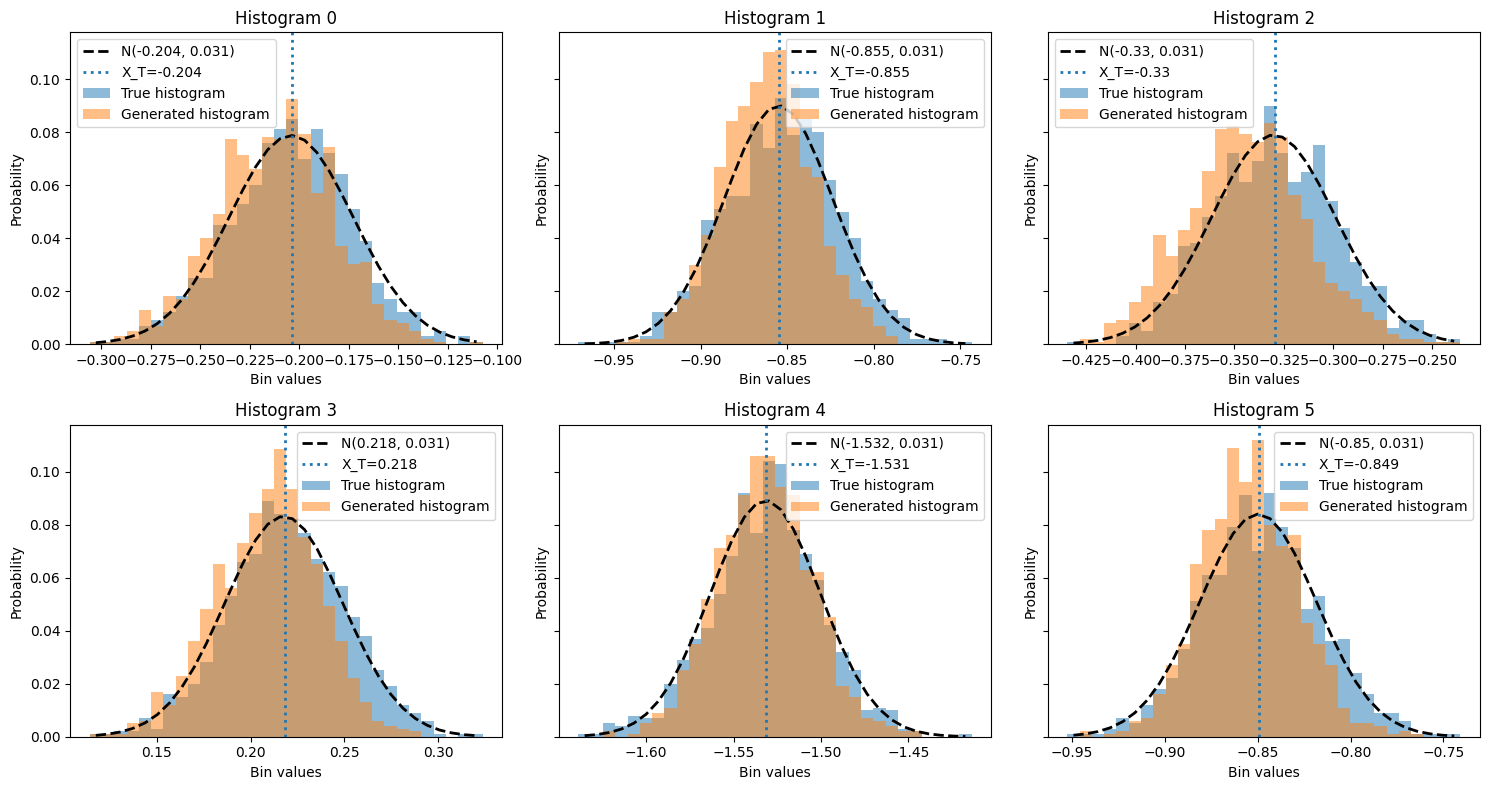

In [20]:
means = sim.means
stds = sim.stds
plot_bin_dist(true_pdfs, generated_pdfs,
            bins_values=bin_edges_list,
            X_T=paths[:, -1],
            stds=stds,
            means=means,
            zoom=False)

# FORWGAN 2 params

In [39]:
# to train a forgan we simulate the J trajectories and the target output is given by the 1-step ahead value
# so just the path are generated and the last values of each trajectory is used as target 
# at inference time the pdf is the one at 1 day ahead
X0_range = (0.0, 0.0)
mu_range = (0.0, 0.0)
sigma_range = (0.5, 0.5)
T = 1.0        # Time horizon (1 year)
N = 253        # Number of time steps
J = 100000        # Number of paths to simulate
SEED=42

# --- Run the Simulation ---
sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

trajectories = sim.get_paths(get_proxy_n=2)
trajectories


array([[ 0.5       , -0.30228534, -0.31041222],
       [ 0.5       ,  0.32629368,  0.29052855],
       [ 0.5       , -0.28817646, -0.27540564],
       ...,
       [ 0.5       ,  1.16569064,  1.1777627 ],
       [ 0.5       , -0.93899815, -0.89581205],
       [ 0.5       , -0.07348507, -0.12749879]], shape=(100000, 3))

In [40]:
paths = trajectories[:, :-1] #shape JxN-1
targets= trajectories[:, -1:] #shape Jx1
pdfs = sim.get_pdf(n_bins=100, P=paths[:, -1], n_steps_ahead=1)
sim.save_configuration('./models/bins/forwgan_debug.json')



Bins saved to models\bins\forwgan_debug.json


In [ ]:
mydata, _, _ = prepare_data(targets, paths)

generator_params = {"hidden_dims": [64, 128, 64], "use_batch_norm":False}
critic_params = {"hidden_dims": [64, 128, 64, 32], 'use_layer_norm':True}
conditional_gan = MyCWGAN(max_epoch=100, name='forwgan_debug', z_noise_dim=24)
conditional_gan.set_generator(condition_size=paths.shape[1], output_dim=targets.shape[1], **generator_params)
conditional_gan.set_discriminator(input_size=targets.shape[1], condition_size=paths.shape[1], **critic_params)
conditional_gan.train(mydata, save_history=False, early_stopping_waiting=10, distance_metric='mse')
conditional_gan.save_models() 
stats = conditional_gan.evaluate_error_distribution(mydata, save_to='forwgan_debug.csv')


Epoch: 0/100, Step: 500, C_loss: 2.5141, G_loss: -1.7260, W_dist: -1.7436, GP: 0.0771
Epoch: 0/100, Step: 1000, C_loss: 5.9492, G_loss: -1.0876, W_dist: -2.5946, GP: 0.3355
Epoch: 0/100, Step: 1500, C_loss: 8.5826, G_loss: -0.9120, W_dist: -1.2535, GP: 0.7329
Epoch: 0/100, Step: 2000, C_loss: -8.5994, G_loss: 5.1192, W_dist: 9.0631, GP: 0.0464
Epoch: 0/100, Step: 2500, C_loss: -3.3837, G_loss: -1.3437, W_dist: 3.5707, GP: 0.0187
Epoch: 0/100, Step: 3000, C_loss: -0.1137, G_loss: -4.1882, W_dist: 0.1613, GP: 0.0048
Epoch: 1/100, Step: 3500, C_loss: 1.4395, G_loss: -5.4917, W_dist: -1.2290, GP: 0.0210
Epoch: 1/100, Step: 4000, C_loss: 1.9599, G_loss: -3.8047, W_dist: -1.1314, GP: 0.0828
Epoch: 1/100, Step: 4500, C_loss: 2.0512, G_loss: -3.1644, W_dist: -0.4444, GP: 0.1607
Epoch: 1/100, Step: 5000, C_loss: 1.5726, G_loss: -3.1848, W_dist: -1.0988, GP: 0.0474
Epoch: 1/100, Step: 5500, C_loss: 1.5800, G_loss: -2.1201, W_dist: -0.4823, GP: 0.1098
Epoch: 1/100, Step: 6000, C_loss: 1.6579, G_l

In [42]:
# data simulation 
# example

X0_range = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
mu_range = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
sigma_range = [0.5, 0.5, 0.5, 0.5, 0.5, 0.5]
T = 1.0        # Time horizon (1 year)
N = 253        # Number of time steps
J = 6       # Number of paths to simulate
SEED=2

sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

trajectories = sim.get_paths(get_proxy_n=2)
paths = trajectories[:, :-1] #shape JxN-1
targets= trajectories[:, -1:] #shape Jx1
pdfs = sim.get_pdf(n_bins=0, P=paths[:, -1], n_steps_ahead=1, mc_sims=1000)

# model 
conditional_gan = MyCWGAN(max_epoch=100, name='forwgan_debug')
conditional_gan.load_models()


mydata, _, _ = prepare_data(targets, paths)
condition, generated = conditional_gan.generate(mydata, get_pdf=True, bins = None)

true_pdfs, generated_pdfs, bin_edges_list = compare_simulated_pdfs(pdfs, generated)

p_values = []
for i, row in enumerate(true_pdfs):
    _, p_value = ks_test_gan_cdf(generated_pdfs[i], row)
    p_values.append(p_value)

test_df = pd.DataFrame({'p_values':p_values})
test_h0 = test_df[test_df['p_values']>0.01]
print("percentage of acceptance of KS test: ", len(test_h0)/len(test_df))

stats = get_error_metrics(true=true_pdfs, generated=generated_pdfs)
for key, metric in stats.items():
    print(key, np.mean(metric))


CGAN config loaded from ./models\forwgan_debug_config.json
Generator loaded from ./models\forwgan_debug_generator.pth
Architecture: MyGenerator
Parameters: {'latent_size': 24, 'condition_size': 2, 'output_dim': 1, 'hidden_dims': [64, 128, 64], 'is_prob': False, 'use_batch_norm': False, 'activation': 'leaky_relu', 'dropout': 0.0}
Discriminator loaded from ./models\forwgan_debug_discriminator.pth
Architecture: MyDiscriminator
Parameters: {'input_size': 1, 'condition_size': 2, 'output_dim': 1, 'hidden_dims': [64, 128, 64, 32], 'use_layer_norm': True, 'activation': 'leaky_relu', 'dropout': 0.0}
shape array (6, 1000)
percentage of acceptance of KS test:  1.0
js_distance 0.14926086598199806
hellinger_distance 0.1301042918549251
tv_distance 0.11926357603931421
emd_distance 0.003643763249445658


In [43]:
for el in mydata:
    print(el)

means = sim.means
stds = sim.stds
print (f'\n means are:{means} \n stds are: {stds}')

(tensor([-0.2412]), tensor([ 0.5000, -0.2036]))
(tensor([-0.8693]), tensor([ 0.5000, -0.8545]))
(tensor([-0.3389]), tensor([ 0.5000, -0.3296]))
(tensor([0.2190]), tensor([0.5000, 0.2182]))
(tensor([-1.4990]), tensor([ 0.5000, -1.5313]))
(tensor([-0.8413]), tensor([ 0.5000, -0.8493]))

 means are:[-0.20404678 -0.85500134 -0.33013867  0.21769917 -1.53179402 -0.84982394] 
 stds are: [0.03143473 0.03143473 0.03143473 0.03143473 0.03143473 0.03143473]


In [44]:
print("means")
for el in generated:
    print(np.mean(el))

print("\n stds")
for el in generated:
    print(np.std(el))

print("\n corrected means")
for el in generated:
    print(np.mean(el) - np.std(el))

print (f'\n means are:{means} \n stds are: {stds}')

means
-0.2002049
-0.84581643
-0.32455787
0.22010756
-1.5113039
-0.8412513

 stds
0.02794134
0.032059755
0.02967404
0.03166909
0.036677476
0.033853345

 corrected means
-0.22814624
-0.87787616
-0.35423192
0.18843846
-1.5479814
-0.87510467

 means are:[-0.20404678 -0.85500134 -0.33013867  0.21769917 -1.53179402 -0.84982394] 
 stds are: [0.03143473 0.03143473 0.03143473 0.03143473 0.03143473 0.03143473]


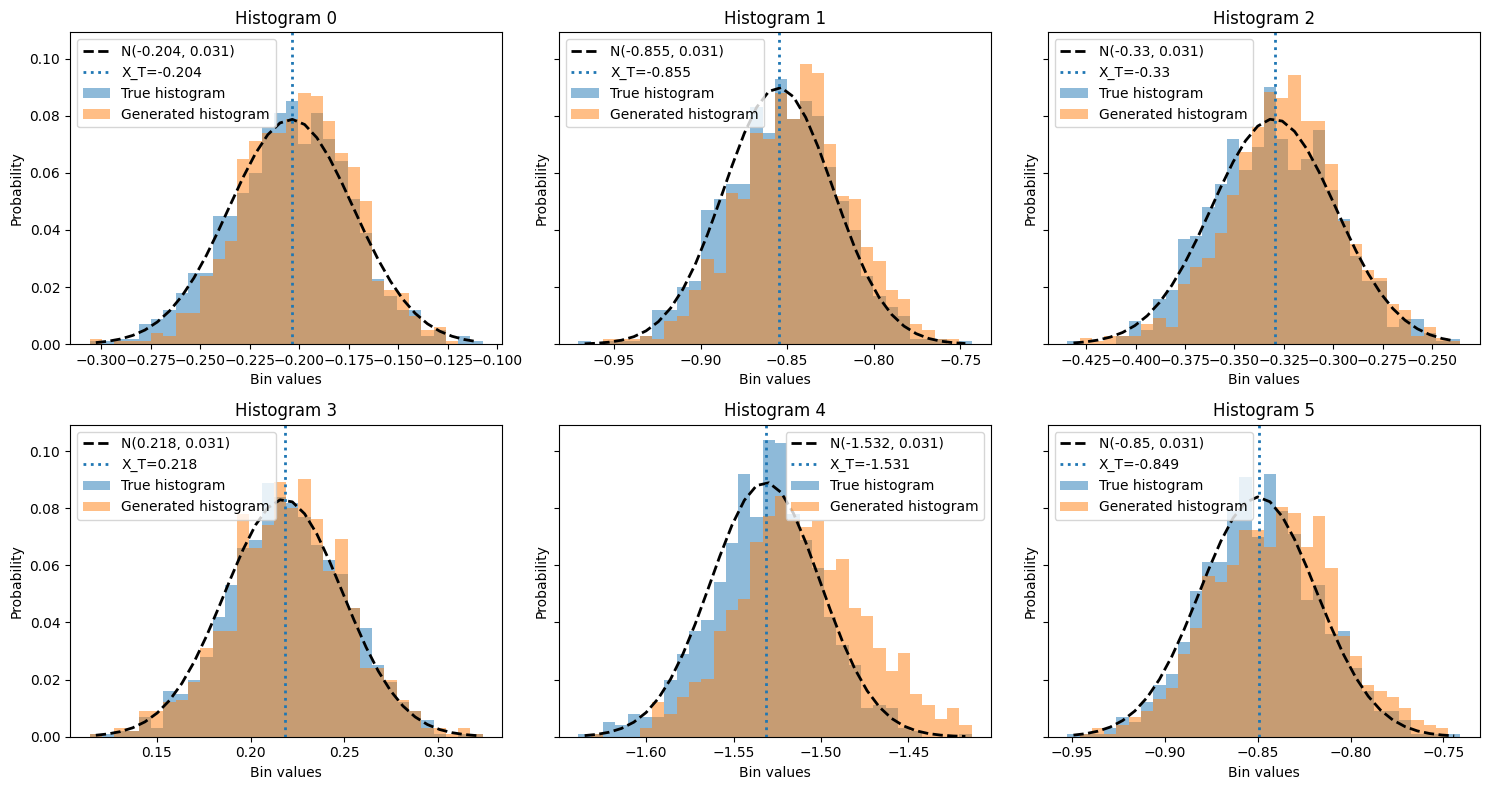

In [45]:
means = sim.means
stds = sim.stds
plot_bin_dist(true_pdfs, generated_pdfs,
            bins_values=bin_edges_list,
            X_T=paths[:, -1],
            stds=stds,
            means=means,
            zoom=False)

# STANDARDIZED FORWGAN

In [2]:
# Training with standardization
X0_range = (0.0, 0.0)
mu_range = (0.0, 0.0)
sigma_range = (0.01, 0.8)
T = round(22/252, 3)
N = 22
J = 100000
SEED = 42

sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                    T=T, N=N, n_simulations=J, seed=SEED)

trajectories = sim.get_paths()
paths = trajectories[:, :-1]  # (J, N-1)
targets = trajectories[:, -1:]  # (J, 1)
pdfs = sim.get_pdf(n_bins=100, P=paths[:, -1], n_steps_ahead=1)
sim.save_configuration('./models/bins/forwgan_std_0.json')

# KEY CHANGE: Add preprocess='standardization'
mydata, X_mean, X_std = prepare_data(targets, paths, preprocess='standardization')


generator_params = {"hidden_dims": [128, 256, 128, 64], "use_batch_norm": False}
critic_params = {"hidden_dims": [128, 256, 256, 128, 64], 'use_layer_norm':True}
conditional_gan = MyCWGAN(max_epoch=100, name='forwgan_std_0', z_noise_dim=32)
conditional_gan.set_generator(condition_size=paths.shape[1], output_dim=targets.shape[1], **generator_params)
conditional_gan.set_discriminator(input_size=targets.shape[1], condition_size=paths.shape[1], **critic_params)
conditional_gan.train(mydata, save_history=False, early_stopping_waiting=10, distance_metric='mse')
conditional_gan.save_models() 



Bins saved to models\bins\forwgan_std_0.json
X tensor shape last axis 1
Epoch: 0/100, Step: 500, C_loss: 7.6800, G_loss: -1.0677, W_dist: -2.5826, GP: 0.5097
Epoch: 0/100, Step: 1000, C_loss: -5.8309, G_loss: 3.5967, W_dist: 7.4754, GP: 0.1644
Epoch: 0/100, Step: 1500, C_loss: 3.8721, G_loss: -0.1904, W_dist: -2.8982, GP: 0.0974
Epoch: 0/100, Step: 2000, C_loss: -5.5270, G_loss: 4.0464, W_dist: 7.0076, GP: 0.1481
Epoch: 0/100, Step: 2500, C_loss: 0.7630, G_loss: -1.4497, W_dist: -0.6301, GP: 0.0133
Epoch: 0/100, Step: 3000, C_loss: -7.4027, G_loss: 8.1732, W_dist: 8.8015, GP: 0.1399
Epoch: 1/100, Step: 3500, C_loss: 10.2469, G_loss: 1.5686, W_dist: -3.0186, GP: 0.7228
Epoch: 1/100, Step: 4000, C_loss: -0.7581, G_loss: -1.3088, W_dist: 1.2510, GP: 0.0493
Epoch: 1/100, Step: 4500, C_loss: 3.1156, G_loss: 0.2799, W_dist: -1.7768, GP: 0.1339
Epoch: 1/100, Step: 5000, C_loss: 8.3075, G_loss: 0.1661, W_dist: -2.9666, GP: 0.5341
Epoch: 1/100, Step: 5500, C_loss: 6.3448, G_loss: -0.2334, W_dis

## KS test

In [3]:
# Testing with standardization and inverse transform
X0_range = (0.0, 0.0)
mu_range = (0.0, 0.0)
sigma_range = (0.05, 0.6)
T = round(22/252, 3)
N = 22
J = 1000
SEED = 2

sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                    T=T, N=N, n_simulations=J, seed=SEED)

trajectories = sim.get_paths()
paths = trajectories[:, :-1]
targets = trajectories[:, -1:]
pdfs = sim.get_pdf(n_bins=0, P=paths[:, -1], n_steps_ahead=1, mc_sims=1000)

# Load model
conditional_gan = MyCWGAN(max_epoch=100, name='forwgan_std_0')
conditional_gan.load_models()

# KEY CHANGE: Standardize test data
mydata, X_mean_test, X_std_test = prepare_data(targets, paths, preprocess='standardization')

# Generate predictions (in STANDARDIZED space)
condition, generated_standardized = conditional_gan.generate(mydata, get_pdf=True, bins=None)

# KEY CHANGE: Inverse transform to original scale
generated = generated_standardized * X_std_test.numpy() + X_mean_test.numpy()

# Now compare original-scale predictions with true PDFs
true_pdfs, generated_pdfs, bin_edges_list = compare_simulated_pdfs(pdfs, generated)

p_values = []
for i, row in enumerate(true_pdfs):
    _, p_value = ks_test_gan_cdf(generated_pdfs[i], row)
    p_values.append(p_value)

test_df = pd.DataFrame({'p_values': p_values})
test_h0 = test_df[test_df['p_values'] > 0.01]
print("percentage of acceptance of KS test: ", len(test_h0)/len(test_df))

stats = get_error_metrics(true=true_pdfs, generated=generated_pdfs)
for key, metric in stats.items():
    print(key, np.mean(metric))

CGAN config loaded from ./models\forwgan_std_0_config.json
Generator loaded from ./models\forwgan_std_0_generator.pth
Architecture: MyGenerator
Parameters: {'latent_size': 32, 'condition_size': 22, 'output_dim': 1, 'hidden_dims': [128, 256, 128, 64], 'is_prob': False, 'use_batch_norm': False, 'activation': 'leaky_relu', 'dropout': 0.0}
Discriminator loaded from ./models\forwgan_std_0_discriminator.pth
Architecture: MyDiscriminator
Parameters: {'input_size': 1, 'condition_size': 22, 'output_dim': 1, 'hidden_dims': [128, 256, 256, 128, 64], 'use_layer_norm': True, 'activation': 'leaky_relu', 'dropout': 0.0}
X tensor shape last axis 1
shape array (1000, 1000)
percentage of acceptance of KS test:  0.295
js_distance 0.48363931277872835
hellinger_distance 0.44305418619030934
tv_distance 0.4519299156464885
emd_distance 0.02007263233539359


## visual

In [4]:
# data simulation 
# example

X0_range = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
mu_range = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
sigma_range = [0.03, 0.07, 0.1, 0.3, 0.5, 0.7]
T = round(22/252, 3)        # Time horizon (monthly)
N = 22        # Number of time steps
J = 6       # Number of paths to simulate
SEED=2

sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

trajectories = sim.get_paths()
paths = trajectories[:, :-1] #shape JxN-1
targets= trajectories[:, -1:] #shape Jx1
pdfs = sim.get_pdf(n_bins=0, P=paths[:, -1], n_steps_ahead=1, mc_sims=1000)

# model 
conditional_gan = MyCWGAN(max_epoch=100, name='forwgan_std_0')
conditional_gan.load_models()

# KEY FIX: Standardize test data
mydata, X_mean_test, X_std_test = prepare_data(targets, paths, preprocess='standardization')

# Generate predictions (in STANDARDIZED space)
condition, generated_standardized = conditional_gan.generate(mydata, get_pdf=True, bins=None)

# KEY FIX: Inverse transform to original scale
generated = generated_standardized * X_std_test.numpy() + X_mean_test.numpy()

# Compare in original scale
true_pdfs, generated_pdfs, bin_edges_list = compare_simulated_pdfs(pdfs, generated)

p_values = []
for i, row in enumerate(true_pdfs):
    _, p_value = ks_test_gan_cdf(generated_pdfs[i], row)
    p_values.append(p_value)

test_df = pd.DataFrame({'p_values':p_values})
test_h0 = test_df[test_df['p_values']>0.01]
print("percentage of acceptance of KS test: ", len(test_h0)/len(test_df))

stats = get_error_metrics(true=true_pdfs, generated=generated_pdfs)
for key, metric in stats.items():
    print(key, np.mean(metric))

CGAN config loaded from ./models\forwgan_std_0_config.json
Generator loaded from ./models\forwgan_std_0_generator.pth
Architecture: MyGenerator
Parameters: {'latent_size': 32, 'condition_size': 22, 'output_dim': 1, 'hidden_dims': [128, 256, 128, 64], 'is_prob': False, 'use_batch_norm': False, 'activation': 'leaky_relu', 'dropout': 0.0}
Discriminator loaded from ./models\forwgan_std_0_discriminator.pth
Architecture: MyDiscriminator
Parameters: {'input_size': 1, 'condition_size': 22, 'output_dim': 1, 'hidden_dims': [128, 256, 256, 128, 64], 'use_layer_norm': True, 'activation': 'leaky_relu', 'dropout': 0.0}
X tensor shape last axis 1
shape array (6, 1000)
percentage of acceptance of KS test:  0.0
js_distance 0.587274474678144
hellinger_distance 0.546264917129804
tv_distance 0.5600451713395638
emd_distance 0.02561022412599515


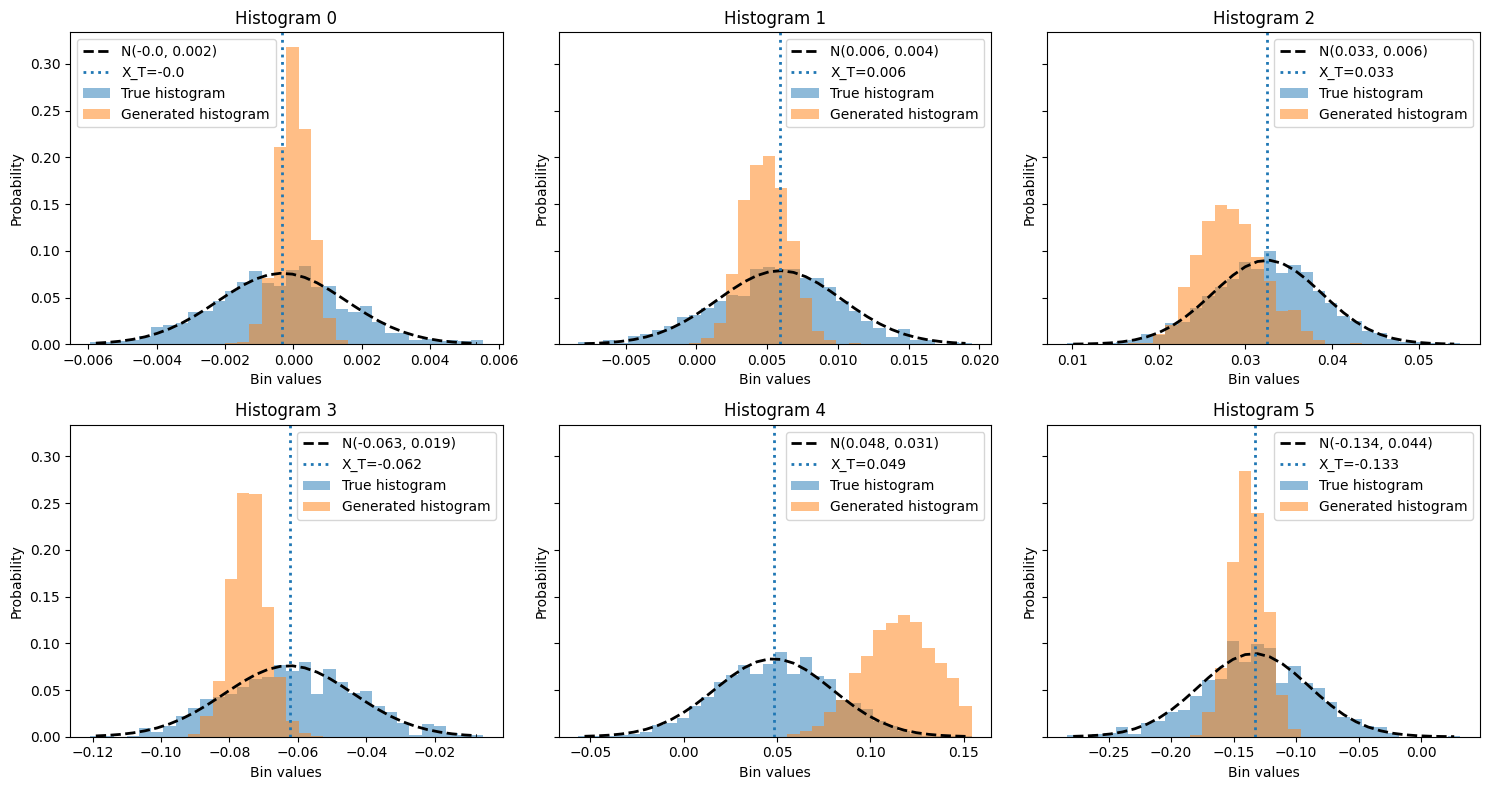

In [5]:
means = sim.means
stds = sim.stds
plot_bin_dist(true_pdfs, generated_pdfs,
            bins_values=bin_edges_list,
            X_T=paths[:, -1],
            stds=stds,
            means=means,
            zoom=False)

# SRForGAN

In [5]:

from torch.utils.data import random_split
from mySRForGAN import MySRForGAN


# ============================================================================
# SHARED SIMULATION PARAMETERS
# (keep consistent between train and test so the sigma ranges overlap)
# ============================================================================

SIM_PARAMS = dict(
    X0_range    = (0.0, 0.0),
    mu_range    = (0.0, 0.0),
    sigma_range = (0.1, 1.2),
    T           = round(22 / 252, 3),   # monthly horizon
    N           = 22,                   # 22 daily steps  →  dt = 1/252
)


# ============================================================================
# TRAIN PIPELINE
# ============================================================================

def train_pipeline(
    J: int           = 100000,
    seed: int        = 42,
    val_fraction:float = 0.1,          # fraction of J used for validation
    z_noise_dim: int = 32,             # same as original MyCGAN example
    n_samples_sr: int = 10,            # m in the paper (3 is fine too)
    scoring_rule: str = "energy",      # 'energy' | 'kernel' | 'energy_kernel'
    max_epoch: int   = 100,
    batch_size: int  = 32, #batch 512
    lr_g: float      = 1e-3,
    save_dir: str    = "./models",
):
    """
    Equivalent to the original MyCGAN train pipeline.

    Key differences vs MyCGAN
    -------------------------
    * No set_discriminator() call — there is no discriminator.
    * train() accepts val_data for real early stopping (the SR loss is
      directly meaningful, unlike the adversarial generator loss).
    * z_noise_dim can be small (32) because there is no mode-collapse
      incentive from a critic.
    """

    # --- 1. Simulate GBM paths -------------------------------------------
    sim = DataSimulator(**SIM_PARAMS, n_simulations=J, seed=seed)
    trajectories = sim.get_paths()          # shape (J, N+1)
    paths   = trajectories[:, :-1]          # (J, N)   — condition window
    targets = trajectories[:, -1:]          # (J, 1)   — next step (target)

    # --- 2. Build TensorDataset  -----------------------------------------
    # prepare_data returns TensorDataset(targets_tensor, paths_tensor)
    full_dataset, _, _ = prepare_data(targets, paths)

    # --- 3. Train / validation split  ------------------------------------
    n_val   = int(len(full_dataset) * val_fraction)
    n_train = len(full_dataset) - n_val
    train_dataset, val_dataset = random_split(
        full_dataset,
        [n_train, n_val],
        generator=torch.Generator().manual_seed(seed),
    )

    # --- 4. Build model  -------------------------------------------------
    model = MySRForGAN(
        max_epoch         = max_epoch,
        batch_size        = batch_size,
        z_noise_dim       = z_noise_dim,
        n_samples_sr      = n_samples_sr,
        scoring_rule      = scoring_rule,
        lr_g              = lr_g,
        early_stopping_patience  = 15,
        early_stopping_min_delta = 1e-6,
        name              = "srforgan",
    )

    # Generator architecture — identical to the original example
    model.set_generator(
        condition_size = paths.shape[1],    # N = 22
        output_dim     = targets.shape[1],  # 1
        hidden_dims    = [128, 256, 128, 64],
        use_batch_norm = True,
    )
    # No set_discriminator() needed

    # Optional: tune kernel bandwidth before training if using kernel score
    if scoring_rule in ("kernel", "energy_kernel"):
        model.tune_kernel_bandwidth(train_dataset)

    # --- 5. Train  -------------------------------------------------------
    history = model.train(
        data         = train_dataset,
        val_data     = val_dataset,   # enables early stopping with a real metric
        save_history = False,
    )

    # --- 6. Save  --------------------------------------------------------
    model.save_models(save_dir)

    return model, history


# ============================================================================
# TEST PIPELINE
# ============================================================================

def test_pipeline(
    J: int        = 1_000,
    seed: int     = 2,
    n_mc: int     = 1_000,       # MC draws for the "true" distribution
    save_dir: str = "./models",
):
    """
    Equivalent to the original MyCGAN test pipeline.

    The generator's `generate(..., get_pdf=True)` method is inherited unchanged
    from MyCGAN and returns shape (J, 1000) — 1000 samples per condition.

    True distributions are obtained from `sim.get_pdf(mc_sims=n_mc)` which
    returns shape (J, n_mc) via Monte Carlo — same convention.
    """

    # --- 1. Simulate test paths  -----------------------------------------
    sim = DataSimulator(**SIM_PARAMS, n_simulations=J, seed=seed)
    trajectories = sim.get_paths()
    paths   = trajectories[:, :-1]   # (J, N)
    targets = trajectories[:, -1:]   # (J, 1)

    # True distributions: n_mc Monte Carlo samples per trajectory
    # get_pdf with mc_sims >= 2 and n_bins=None returns raw samples (J, n_mc)
    true_samples = sim.get_pdf(n_bins=0, P=paths[:, -1], n_steps_ahead=1, mc_sims=n_mc)

    # --- 2. Load model  --------------------------------------------------
    model = MySRForGAN(name="srforgan")
    model.load_models(save_dir)

    # --- 3. Generate predictions  ----------------------------------------
    # prepare_data wraps (targets, paths) into a TensorDataset
    test_dataset, _, _ = prepare_data(targets, paths)

    # generate() is inherited from MyCGAN:
    #   get_pdf=True  → draws 1 000 noise vectors per condition
    #   returns (conditions, simulations)  shapes (J, N) and (J, 1000)
    _, generated = model.generate(test_dataset, get_pdf=True, bins=None)

    # --- 4. Discretise both into histograms (same bins per sample)  ------
    true_pdfs, generated_pdfs, bin_edges_list = compare_simulated_pdfs(
        true_samples, generated
    )

    # --- 5. KS test  -----------------------------------------------------
    p_values = []
    for i, row in enumerate(true_pdfs):
        _, p_value = ks_test_gan_cdf(generated_pdfs[i], row)
        p_values.append(p_value)

    test_df = pd.DataFrame({"p_values": p_values})
    test_h0 = test_df[test_df["p_values"] > 0.01]
    acceptance_rate = len(test_h0) / len(test_df)
    print(f"\nKS test acceptance rate (H0: same distribution): {acceptance_rate:.3%}")

    # --- 6. Distribution-quality metrics  --------------------------------
    stats = get_error_metrics(
        true      = np.array(true_pdfs),
        generated = np.array(generated_pdfs),
    )
    for key, metric in stats.items():
        print(f"{key}: {np.mean(metric):.6f}")

    return test_df, stats


# ============================================================================
# ENTRY POINT
# ============================================================================

if __name__ == "__main__":
    print("=" * 60)
    print("TRAIN")
    print("=" * 60)
    model, history = train_pipeline()

    print("\n" + "=" * 60)
    print("TEST")
    print("=" * 60)
    test_df, stats = test_pipeline()

TRAIN
Epoch    0/100  Train SR: 0.082569  Val SR: 0.058705
Epoch   10/100  Train SR: 0.051555  Val SR: 0.049091
Epoch   20/100  Train SR: 0.050268  Val SR: 0.048250
Epoch   30/100  Train SR: 0.049540  Val SR: 0.048136
Epoch   40/100  Train SR: 0.048960  Val SR: 0.047761
Epoch   50/100  Train SR: 0.048973  Val SR: 0.047874
Epoch   60/100  Train SR: 0.048838  Val SR: 0.048138

Early stopping at epoch 68. Best val SR: 0.047316

Training finished in 1651.1s.
Generator saved to ./models\srforgan_generator.pth
SR config saved to ./models\srforgan_config.json

TEST
SR config loaded from ./models\srforgan_config.json
Generator loaded from ./models\srforgan_generator.pth
Architecture: MyGenerator
Parameters: {'latent_size': 32, 'condition_size': 22, 'output_dim': 1, 'hidden_dims': [128, 256, 128, 64], 'is_prob': False, 'use_batch_norm': True, 'activation': 'leaky_relu', 'dropout': 0.0}
shape array (1000, 1000)

KS test acceptance rate (H0: same distribution): 100.000%
js_distance: 0.202880
hell

true samples shape : (4, 1000)
SR config loaded from ./models\srforgan_config.json
Generator loaded from ./models\srforgan_generator.pth
Architecture: MyGenerator
Parameters: {'latent_size': 32, 'condition_size': 22, 'output_dim': 1, 'hidden_dims': [128, 256, 128, 64], 'is_prob': False, 'use_batch_norm': True, 'activation': 'leaky_relu', 'dropout': 0.0}
shape array (4, 1000)
generated shape    : (4, 1000)
KS acceptance rate: 1.0
js_distance 0.1856816684895195
hellinger_distance 0.16338127708662356
tv_distance 0.1481482492922477
emd_distance 0.00781954220106932


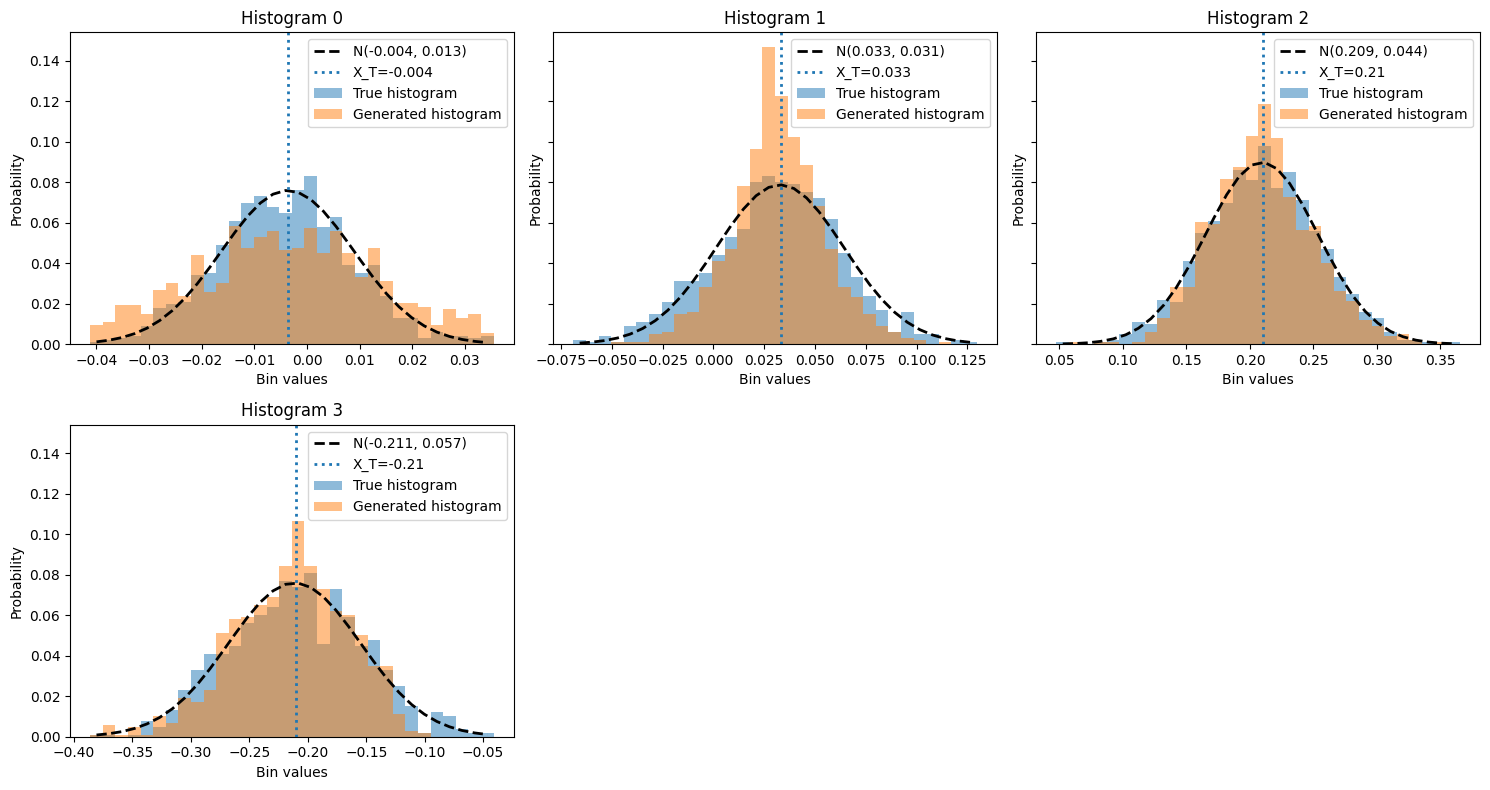

In [6]:
X0_range    = [0.0, 0.0, 0.0, 0.0]
mu_range    = [0.0, 0.0, 0.0, 0.0]
sigma_range = [0.2, 0.5, 0.7, 0.9]
T    = round(22 / 252, 3)
N    = 22
J    = 4
SEED = 2
 
val = DataSimulator(
    X0_range    = X0_range,
    mu_range    = mu_range,
    sigma_range = sigma_range,
    T=T, N=N, n_simulations=J, seed=SEED,
)
 
 
# ── Cell 2 : generate paths ───────────────────────────────────────────────────
#
# load_configuration() is REMOVED.
# The original call loaded training-time bin edges so the histograms matched.
# MySRForGAN never produces bins at training time, so nothing to load.
 
trajectories = val.get_paths()
paths   = trajectories[:, :-1]   # (J, N)  — condition window
targets = trajectories[:, -1:]   # (J, 1)  — next step (target)
 
 
# ── Cell 3 : true distributions via Monte Carlo ───────────────────────────────
#
# Your original used n_bins=0. Both 0 and 5 work, but here is why any value
# in 1–10 is needed:
#
#   get_pdf(n_bins=None) → early return of column_stack((mean,std)) shape (J,2)
#   get_pdf(n_bins=5, mc_sims=1000):
#       • n_bins is not None  → skips the early return
#       • mc_sims >= 2        → enters the Monte Carlo branch
#       • n_bins <= 10        → returns raw samples (J, 1000) instead of histogram
#
# sim.means and sim.stds are always set as a side-effect at the top of get_pdf,
# so they are available regardless of which branch is taken.
 
pdfs  = val.get_pdf(n_steps_ahead=1, n_bins=0, P=paths[:, -1], mc_sims=1000)
means = val.means   # (J,) — analytical means for the normal overlay
stds  = val.stds    # (J,) — analytical stds
 
print(f"true samples shape : {pdfs.shape}")     # expect (6, 1000)
 
 
# ── Cell 4 : load model and generate ─────────────────────────────────────────
#
# MySRForGAN.load_models() only restores the generator — no discriminator key
# error that the base MyCGAN.load_models() would raise here.
 
model = MySRForGAN(name="srforgan")
model.load_models()
 
mydata, _, _ = prepare_data(targets, paths)
 
# generate() is inherited unchanged from MyCGAN.
# get_pdf=True → draws 1000 noise vectors per condition → shape (J, 1000)
condition, generated = model.generate(mydata, get_pdf=True, bins=None)
 
print(f"generated shape    : {generated.shape}")  # expect (6, 1000)
 
 
# ── Cell 5 : discretise into histograms ──────────────────────────────────────
#
# compare_simulated_pdfs bins both arrays with the same edges per row,
# so the (J, 1000) shapes must match — they do after the n_bins fix above.
 
true_pdfs, generated_pdfs, bin_edges_list = compare_simulated_pdfs(
    pdfs, generated
)
 
 
# ── Cell 6 : KS test ─────────────────────────────────────────────────────────
 
p_values = []
for i, row in enumerate(true_pdfs):
    _, p_value = ks_test_gan_cdf(generated_pdfs[i], row)
    p_values.append(p_value)
 
test_df = pd.DataFrame({"p_values": p_values})
test_h0 = test_df[test_df["p_values"] > 0.01]
print("KS acceptance rate:", len(test_h0) / len(test_df))
 
 
# ── Cell 7 : error metrics ────────────────────────────────────────────────────
 
stats = get_error_metrics(true=true_pdfs, generated=generated_pdfs)
for key, metric in stats.items():
    print(key, np.mean(metric))
 
 
# ── Cell 8 : visual comparison ───────────────────────────────────────────────
#
# Identical to the original call — means/stds overlay the analytical normal,
# X_T marks the last observed log-price on each subplot.
 
plot_bin_dist(
    true_pdfs,
    generated_pdfs,
    bins_values = bin_edges_list,
    X_T         = paths[:, -1].tolist(),
    means       = means,
    stds        = stds,
    zoom        = False,
)